# Bergen City Bike — Trip Data Exploration

Demo notebook for the CMK talk (Data Saturday Rheinland, 11 July 2026).

This notebook reads Bergen's open bike-share trip data (Jan–Jul 2026), does a quick look at it, and builds one chart.
That's the whole job of this notebook: be a real Fabric item with real data, so encryption has something to actually protect.

**Before running:** attach a Lakehouse to this notebook, and upload the 7 monthly CSVs into a `Files/bike_data/` folder in that Lakehouse.

In [10]:
# Read all monthly CSVs at once from the Lakehouse Files folder.
# Adjust the path below if your folder is named differently.

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv("Files/bike_data/*.csv")
)

print(f"Loaded {df.count():,} trips.")

StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 13, Finished, Available, Finished, False)

Loaded 118,941 trips.


## What are we looking at?

In [11]:
df.printSchema()

StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 14, Finished, Available, Finished, False)

root
 |-- started_at: timestamp (nullable = true)
 |-- ended_at: timestamp (nullable = true)
 |-- duration: integer (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_description: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: integer (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_description: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)



In [12]:
display(df.limit(10))

StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 15, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 2bc07fa2-7222-43b8-9bc7-35acbaeb2581)

## Time range and basic shape of the data

In [13]:
from pyspark.sql import functions as F

df.select(
    F.min("started_at").alias("earliest_trip"),
    F.max("started_at").alias("latest_trip"),
    F.count("*").alias("total_trips"),
    F.round(F.avg("duration") / 60, 1).alias("avg_duration_minutes"),
).show(truncate=False)

StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 16, Finished, Available, Finished, False)

+-----------------------+-----------------------+-----------+--------------------+
|earliest_trip          |latest_trip            |total_trips|avg_duration_minutes|
+-----------------------+-----------------------+-----------+--------------------+
|2026-01-01 06:04:41.443|2026-07-07 08:55:19.211|118941     |10.3                |
+-----------------------+-----------------------+-----------+--------------------+



## Trips per month

One clean chart — enough to point at on stage without spending the whole demo on data exploration.

In [14]:
monthly = (
    df.withColumn("trip_month", F.date_format("started_at", "yyyy-MM"))
      .groupBy("trip_month")
      .count()
      .orderBy("trip_month")
)

monthly_pd = monthly.toPandas()
monthly_pd

StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 17, Finished, Available, Finished, False)

,trip_month,count
0,2026-01,10209
1,2026-02,11837
2,2026-03,15356
3,2026-04,25572
4,2026-05,26010
5,2026-06,25542
6,2026-07,4415


StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 18, Finished, Available, Finished, False)

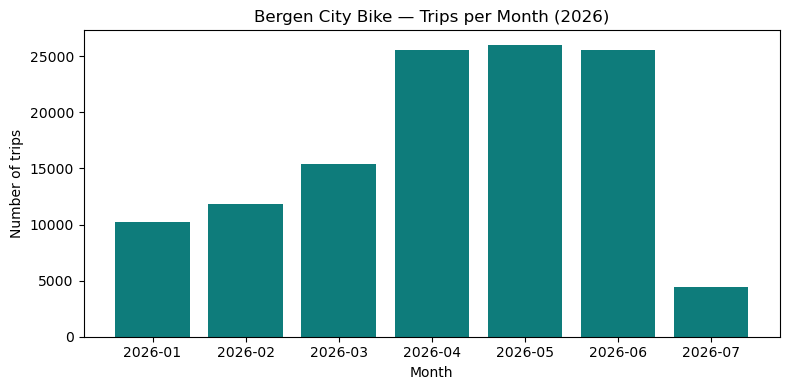

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(monthly_pd["trip_month"], monthly_pd["count"], color="#0E7C7B")
plt.title("Bergen City Bike — Trips per Month (2026)")
plt.xlabel("Month")
plt.ylabel("Number of trips")
plt.tight_layout()
plt.show()

## Bonus: the 10 busiest start stations

Optional — only run this if you have time on stage, it's not essential to the CMK story.

In [16]:
top_stations = (
    df.groupBy("start_station_name")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

display(top_stations)

StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 19, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a80d424b-d470-4b85-ba07-b84008320aa3)

---

### After revocking the keys



In [8]:
# Read all monthly CSVs at once from the Lakehouse Files folder.
# Adjust the path below if your folder is named differently.

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv("Files/bike_data/*.csv")
)

print(f"Loaded {df.count():,} trips.")

StatementMeta(, 264de5b4-d2df-40c6-b101-bd4b1dc5bae1, 11, Finished, Available, Finished, False)

Loaded 118,941 trips.


In [18]:
from pyspark.sql import functions as F
top_stations = (
    df.groupBy("start_station_name")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

display(top_stations)

StatementMeta(, 49000b0c-e4e7-4438-8163-07ca57253043, 21, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 2386dfc0-4669-4300-af52-0b7d54d07976)